<a href="https://colab.research.google.com/github/gogulasaimounika/Predictive-Analytics-lab/blob/Shopping-History/Shopping_History.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import os

# Load purchase history dataset
# The UnicodeDecodeError suggests an issue with the file encoding.
# Trying to read with a different encoding like 'latin1'.
try:
    purchase_df = pd.read_csv('Shopping_data.csv', encoding='latin1')
except UnicodeDecodeError:
    purchase_df = pd.read_csv('Shopping_data.csv', encoding='utf-8')

print("Original columns:", purchase_df.columns)

# Rename columns for clarity
purchase_df = purchase_df.rename(columns={
    'CustomerID': 'user_id',
    'Genre': 'gender',
    'Age': 'age',
    'Annual Income (k$)': 'annual_income',
    'Spending Score (1-100)': 'spending_score'
})

print("\nRenamed columns:", purchase_df.columns)

# Drop rows with missing user_id
purchase_df.dropna(subset=['user_id'], inplace=True)

# Convert user_id to integer
purchase_df['user_id'] = purchase_df['user_id'].astype(int)

display(purchase_df.head())

Original columns: Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

Renamed columns: Index(['user_id', 'gender', 'age', 'annual_income', 'spending_score'], dtype='object')


,user_id,gender,age,annual_income,spending_score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


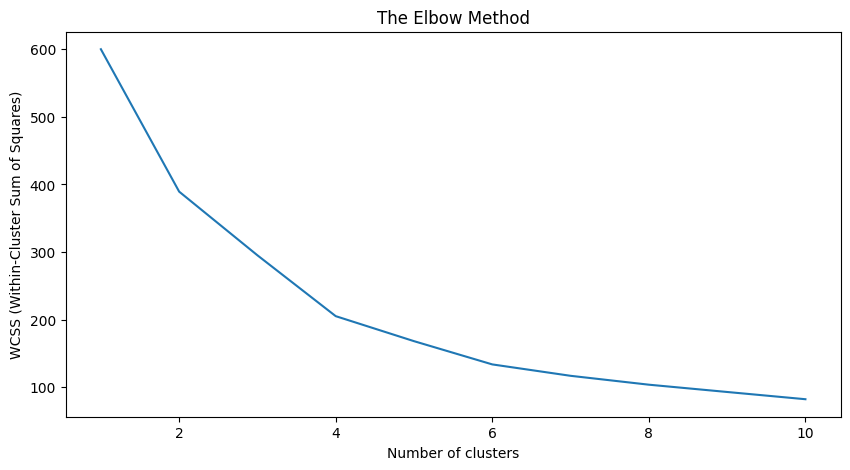

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Select features for clustering
features = ['age', 'annual_income', 'spending_score']
X = purchase_df[features]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine the optimal number of clusters using the Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.show()

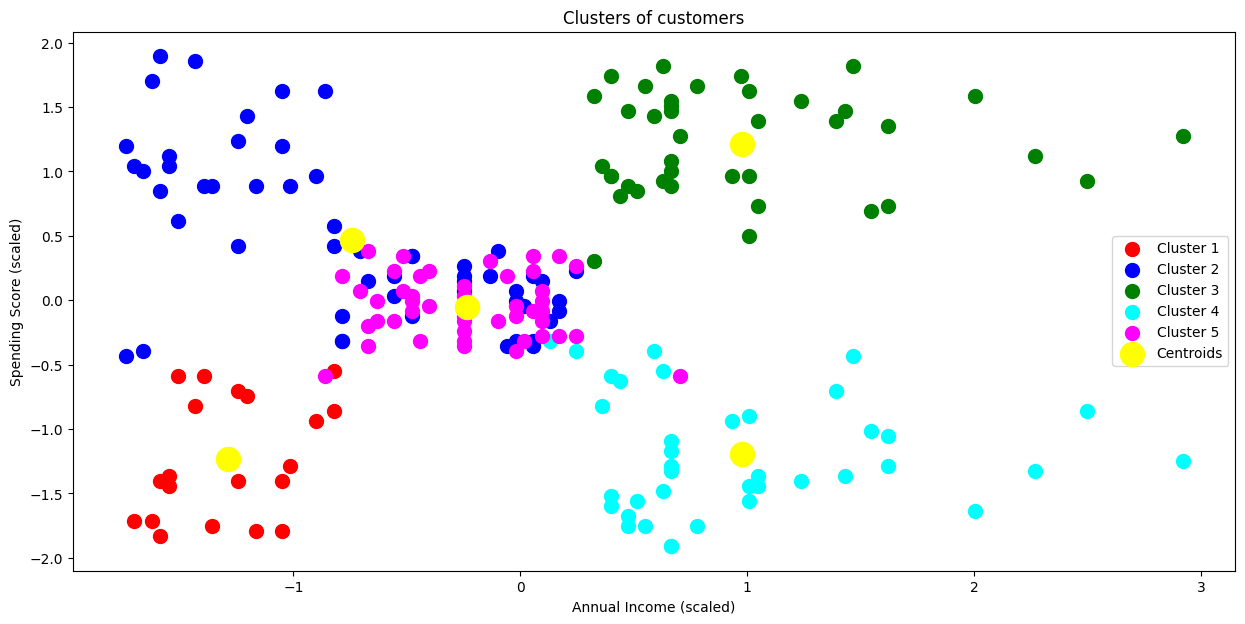

In [ ]:
# Apply K-Means with the optimal number of clusters (k=5)
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Add the cluster labels to the original dataframe
purchase_df['cluster'] = y_kmeans

# Visualize the clusters
plt.figure(figsize=(15, 7))
plt.scatter(X_scaled[y_kmeans == 0, 1], X_scaled[y_kmeans == 0, 2], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X_scaled[y_kmeans == 1, 1], X_scaled[y_kmeans == 1, 2], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X_scaled[y_kmeans == 2, 1], X_scaled[y_kmeans == 2, 2], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X_scaled[y_kmeans == 3, 1], X_scaled[y_kmeans == 3, 2], s = 100, c = 'cyan', label = 'Cluster 4')
plt.scatter(X_scaled[y_kmeans == 4, 1], X_scaled[y_kmeans == 4, 2], s = 100, c = 'magenta', label = 'Cluster 5')
plt.scatter(kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 2], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.legend()
plt.show()